In [21]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator
from scipy.linalg import eigh
from numpy import pi, exp, sqrt, real, imag

# ================================== 基本设置 ==================================
N = 2**4
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
dx = 2*pi/N

def kinetic_operator(n, dt):
    qc = QuantumCircuit(n)
    qc.rz(-2**(n-1)*dt, n-1)
    for i in range(n):
        qc.rz(2**(n-i-2)*dt, n-i-1)
    for i in range(1, n):
        qc.cx(n-1, n-i-1)
        qc.rz(-2**(2*n-i-2)*dt, n-i-1)
        qc.cx(n-1, n-i-1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n-i-1, n-j-1)
                qc.rz(2**(2*n-i-j-4)*dt, n-j-1)
                qc.cx(n-i-1, n-j-1)
    return qc

def evolve(nx, ny, dt, initial_state):
    q_num = nx + ny + 1
    circ = QuantumCircuit(q_num)
    circ.initialize(initial_state)
    circ.barrier()

    from qiskit.circuit.library import QFT
    QFT_x = QFT(nx)
    QFT_y = QFT(ny)
    IQFT_x = QFT(nx).inverse()
    IQFT_y = QFT(ny).inverse()

    kinetic_x = kinetic_operator(nx, dt)
    kinetic_y = kinetic_operator(ny, dt)

    circ.append(QFT_x, range(nx))
    circ.append(QFT_y, range(nx, nx+ny))
    circ.barrier()

    circ.append(kinetic_x, range(nx))
    circ.append(kinetic_y, range(nx, nx+ny))
    circ.barrier()

    circ.append(IQFT_x, range(nx))
    circ.append(IQFT_y, range(nx, nx+ny))
    circ.save_statevector()

    simulator = AerSimulator(method='statevector')
    circ = transpile(circ, simulator)
    result = simulator.run(circ).result()
    return np.array(result.data(0)['statevector'])

# ================================== 初始条件 ==================================
x0, y0 = 0, 0
R = np.sqrt((X - x0)**2 + (Y - y0)**2)
sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)
initial_state = np.array([psi1_0, psi2_0]).reshape(-1)
initial_state = initial_state / np.linalg.norm(initial_state)

# ================================== Shadow 验证模块 ==================================
def get_density_operators(nx, ny, points):
    def index(ix, iy): return iy * (2**nx) + ix
    obs = []
    for (ix, iy) in points:
        idx = index(ix, iy)
        O = np.zeros((2*N*N, 2*N*N), dtype=complex)
        O[idx, idx] = 1.0
        O[idx+N*N, idx+N*N] = 1.0
        obs.append(O)
    return obs

def get_expectation(statevec, observables):
    return [np.real(statevec.conj().T @ (O @ statevec)) for O in observables]

def build_shadow_evolution_circuit(H_S, init_expvals, t):
    M = len(init_expvals)
    psi0 = np.array(init_expvals, dtype=complex)
    psi0 /= np.linalg.norm(psi0)
    n_shadow = int(np.ceil(np.log2(M)))
    dim = 2**n_shadow

    init_state = np.zeros(dim, dtype=complex)
    init_state[:M] = psi0

    eigvals, V = eigh(H_S)
    U_s = V @ np.diag(np.exp(-1j * eigvals * t)) @ V.conj().T
    U_pad = np.eye(dim, dtype=complex)
    U_pad[:M, :M] = U_s

    circ = QuantumCircuit(n_shadow)
    circ.initialize(init_state, range(n_shadow))
    circ.append(Operator(U_pad), range(n_shadow))
    circ.save_statevector()
    return circ, n_shadow

# ========== 参数与观测点 ==========
nx = ny = 4
dt = 1.0
# selected_points = [(8, 8), (16, 16), (24, 24)]
# observables = get_density_operators(nx, ny, selected_points)

all_points = [(ix, iy) for ix in range(N) for iy in range(N)]
observables = get_density_operators(nx, ny, all_points)


# ========== 构造 H_S ==========
state_0 = evolve(nx, ny, 0.0, initial_state)
state_eps = evolve(nx, ny, 1e-4, initial_state)
delta_state = (state_eps - state_0) / 1e-4
M = len(observables)
H_S = np.zeros((M, M), dtype=complex)
for m in range(M):
    for n in range(M):
        O_n = observables[n]
        expect_0 = np.real(state_0.conj().T @ (O_n @ state_0))
        expect_1 = np.real(state_eps.conj().T @ (O_n @ state_eps))
        dO_dt = (expect_1 - expect_0) / 1e-4
        H_S[m, n] = 1j * dO_dt  # [H, O] = -i dO/dt → H_S ≈ i dO/dt

# ========== 演化并对比 ==========
init_expect = get_expectation(state_0, observables)
shadow_circ, n_shadow = build_shadow_evolution_circuit(H_S, init_expect, t=dt)
sim = AerSimulator(method='statevector')
shadow_circ = transpile(shadow_circ, sim)
result = sim.run(shadow_circ).result()
from qiskit.quantum_info import Statevector
statevec_shadow = np.array(Statevector(result.data(0)['statevector']))

shadow_expect = np.real(statevec_shadow[:M]) * np.linalg.norm(init_expect)

state_1 = evolve(nx, ny, dt, initial_state)
full_expect = get_expectation(state_1, observables)

# ========== 输出 ==========
print(f"\n✅ Shadow Hamiltonian Simulation 验证 (t = {dt}):")
for i, pt in enumerate(all_points):
    err = abs(full_expect[i] - shadow_expect[i])
    print(f"  网格点 {pt}:  全态 = {full_expect[i]:.6f},  影子 = {shadow_expect[i]:.6f},  误差 = {err:.2e}")



✅ Shadow Hamiltonian Simulation 验证 (t = 1.0):
  网格点 (0, 0):  全态 = 0.004791,  影子 = 0.003906,  误差 = 8.85e-04
  网格点 (0, 1):  全态 = 0.005081,  影子 = 0.003918,  误差 = 1.16e-03
  网格点 (0, 2):  全态 = 0.005785,  影子 = 0.003962,  误差 = 1.82e-03
  网格点 (0, 3):  全态 = 0.005436,  影子 = 0.004101,  误差 = 1.34e-03
  网格点 (0, 4):  全态 = 0.004107,  影子 = 0.004365,  误差 = 2.59e-04
  网格点 (0, 5):  全态 = 0.003173,  影子 = 0.004680,  误差 = 1.51e-03
  网格点 (0, 6):  全态 = 0.002626,  影子 = 0.004802,  误差 = 2.18e-03
  网格点 (0, 7):  全态 = 0.002110,  影子 = 0.004535,  误差 = 2.43e-03
  网格点 (0, 8):  全态 = 0.001915,  影子 = 0.003893,  误差 = 1.98e-03
  网格点 (0, 9):  全态 = 0.002173,  影子 = 0.003265,  误差 = 1.09e-03
  网格点 (0, 10):  全态 = 0.002753,  影子 = 0.003008,  误差 = 2.55e-04
  网格点 (0, 11):  全态 = 0.003301,  影子 = 0.003143,  误差 = 1.58e-04
  网格点 (0, 12):  全态 = 0.004179,  影子 = 0.003455,  误差 = 7.24e-04
  网格点 (0, 13):  全态 = 0.005464,  影子 = 0.003717,  误差 = 1.75e-03
  网格点 (0, 14):  全态 = 0.005761,  影子 = 0.003849,  误差 = 1.91e-03
  网格点 (0, 15):  全态 = 0.005042,  影

In [18]:
# 全态演化结果
state_1 = evolve(nx, ny, dt, initial_state)
full_rho = get_expectation(state_1, observables)
full_rho_map = np.array(full_rho).reshape(N, N)

# 影子态重建
shadow_expect = np.real(statevec_shadow[:N*N]) * np.linalg.norm(init_expect)
shadow_rho_map = np.array(shadow_expect).reshape(N, N)


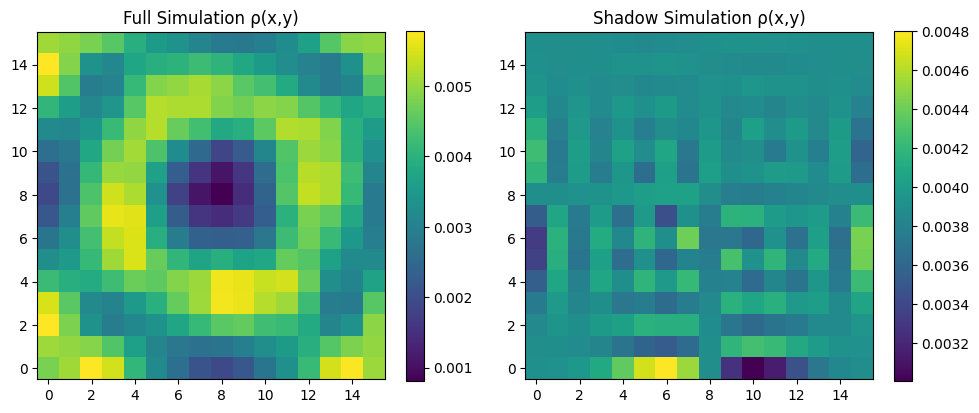

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im0 = axs[0].imshow(full_rho_map, origin='lower', cmap='viridis')
axs[0].set_title("Full Simulation ρ(x,y)")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(shadow_rho_map, origin='lower', cmap='viridis')
axs[1].set_title("Shadow Simulation ρ(x,y)")
plt.colorbar(im1, ax=axs[1])
plt.tight_layout()
plt.show()
